Come prima cosa importo le librerie che mi saranno utili, e carico il dataset grezzo (grazie Ali)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import  LabelEncoder, StandardScaler 

path = "../power_nap_vs_coffee_effectiveness_dataset.csv"  # cambiare se serve
df = pd.read_csv(path) #df = nome standardizzato per DataFrame

df.shape, df.head(), df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   participant_id                 500 non-null    int64  
 1   age                            500 non-null    int64  
 2   occupation                     500 non-null    str    
 3   sleep_hours_previous_night     500 non-null    float64
 4   intervention_type              500 non-null    str    
 5   intervention_duration_minutes  500 non-null    int64  
 6   alertness_score_before         500 non-null    int64  
 7   alertness_score_after          500 non-null    int64  
 8   productivity_rating            500 non-null    int64  
 9   mood_rating                    500 non-null    int64  
 10  side_effects                   293 non-null    str    
dtypes: float64(1), int64(7), str(3)
memory usage: 43.1 KB


((500, 11),
    participant_id  age            occupation  sleep_hours_previous_night  \
 0               1   24  Working Professional                         5.4   
 1               2   37               Student                         5.6   
 2               3   32  Working Professional                         4.4   
 3               4   28               Student                         6.9   
 4               5   25  Working Professional                         4.7   
 
   intervention_type  intervention_duration_minutes  alertness_score_before  \
 0         Power Nap                             15                      62   
 1         Power Nap                             30                      67   
 2            Coffee                             30                      44   
 3            Coffee                             30                      59   
 4         Power Nap                             30                      40   
 
    alertness_score_after  productivity_rating  

Queste sono le caratteristiche del dataframe. Ci sono 500-293 missing values nella colonna Side Effects (grazie Ali) che potrebbe essere una delle principali per quanto riguarda futura analisi dati usando caffè / power-nap come target

Sembra che i valri nulli siano semplciemente interpretabili come "nessun side effect" e quindi non sono valori mancanti ma informativi. Vanno sostituiti con valori nulli

________________________________________________________________________________

**CONTROLLO QUALITA'**

In [3]:
# Missing
(df.isna().mean().sort_values(ascending=False) * 100).round(1)

# Duplicati (participant_id dovrebbe essere unico)
df.duplicated().sum(), df["participant_id"].duplicated().sum()

# Valori strani / range rapidi
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,500.0,NaN,NaN,NaN,250.5,144.481833,1.0,125.75,250.5,375.25,500.0
age,500.0,NaN,NaN,NaN,30.928,8.147612,18.0,24.0,31.0,38.0,44.0
occupation,500,3,Student,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours_previous_night,500.0,NaN,NaN,NaN,6.0586,1.136842,4.0,5.1,6.1,7.0,8.0
intervention_type,500,2,Coffee,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intervention_duration_minutes,500.0,NaN,NaN,NaN,22.3,5.654551,15.0,15.0,20.0,25.0,30.0
alertness_score_before,500.0,NaN,NaN,NaN,57.38,9.943306,40.0,49.0,58.0,65.0,74.0
alertness_score_after,500.0,NaN,NaN,NaN,71.23,11.420067,46.0,62.0,72.0,79.25,97.0
productivity_rating,500.0,NaN,NaN,NaN,5.374,2.842232,1.0,3.0,5.0,8.0,10.0
mood_rating,500.0,NaN,NaN,NaN,5.422,2.908752,1.0,3.0,5.0,8.0,10.0


Ovviamente, provando ad applicare statistiche numeriche a variabili inadeguate otteniamo una fucilata di NaN, questo è da attendersi.
Nello specifico, avendo lanciato "describe" con la specifica di includere "all", i risultati NaN attesi sono i seguenti:
 - Variabili numeriche: NaN = unique, tip, freq (sono analisi categoriali)
 - Variabili categoriali: NaN = mean, std, min, tutte quelle dei percentili (sono analisi numeriche)

Tuttavia è notevole la riga "side_effects", dove falliscono anche le Categoriali. Come ha giustamente detto Alice, tocca intervenire per rifinire quella colonna, oltre che a normalizzare i dati (SD troppo alte e mean strane dei valori numerici indicano) -> elaborare meglio <3

______________________________________________________________________________

**PULIZIA DATI**

In questo blocco succedono 3 cose importanti:

1 - tolgo i duplicati (è inutile nel nostro dataset, non abbiamo duplicati, ma è buona pratica)

2 - cambio i NaN con "none" ora che abbiamo deciso che i missing data sono informativi, e significano "assenza di effetti collaterali"

3 - "intervention Type", "side effects" e "occupation" sono emerse come variabili string dall'info. Pandas ha il datatype "category" per rendere le variabili categriali analizzabili, quindi le converto come variabili di quel tipo

In [4]:
df = df.drop_duplicates(subset=["participant_id"]).copy() 
#questa cosa è inutile. Il dataset è già privo di duplicati, ma è dicono sia buona pratica fare comunque questo tipo di operazione, allora la faccio.

#riempo il dataset sostituendo a NaN il valore stringa "None"
df["side_effects"] = df["side_effects"].fillna("None")

# Categorie
df["intervention_type"] = df["intervention_type"].astype("category")
df["occupation"] = df["occupation"].astype("category")
df["side_effects"] = df["side_effects"].astype("category")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   participant_id                 500 non-null    int64   
 1   age                            500 non-null    int64   
 2   occupation                     500 non-null    category
 3   sleep_hours_previous_night     500 non-null    float64 
 4   intervention_type              500 non-null    category
 5   intervention_duration_minutes  500 non-null    int64   
 6   alertness_score_before         500 non-null    int64   
 7   alertness_score_after          500 non-null    int64   
 8   productivity_rating            500 non-null    int64   
 9   mood_rating                    500 non-null    int64   
 10  side_effects                   500 non-null    category
dtypes: category(3), float64(1), int64(7)
memory usage: 32.9 KB


Se adesso provo a runnare nuovamente le Info, vedo che non ho più NaN e che le variabili "string" sono ora "category"

________________________________________________________________________________

**CORRELAZIONE FRA LE FEATURE**

Allora, oggi sono stata ispirata da Pellungrini e ho deciso di fare alcune delle indagini che fa lui tipo vedere quali feature sono strettamente correlate per scegliere se dropparne una o più di una. Decido di fare una copia con one hot encoding, che serve per la correlazione. Sovrascrivo volutamente il dataset, perchè tanto ci serve il dataframe senza dati categoriali (ho visto che pure con le variabili category non funziona)

In [6]:
le = LabelEncoder()

df_encoded = df.copy()

df_encoded["intervention_type"] = le.fit_transform(df["intervention_type"])
df_encoded = pd.get_dummies(df_encoded, columns=["occupation"])
df_encoded = pd.get_dummies(df_encoded, columns=['side_effects'])
print(df_encoded.head())


   participant_id  age  sleep_hours_previous_night  intervention_type  \
0               1   24                         5.4                  1   
1               2   37                         5.6                  1   
2               3   32                         4.4                  0   
3               4   28                         6.9                  0   
4               5   25                         4.7                  1   

   intervention_duration_minutes  alertness_score_before  \
0                             15                      62   
1                             30                      67   
2                             30                      44   
3                             30                      59   
4                             30                      40   

   alertness_score_after  productivity_rating  mood_rating  \
0                     77                    5           10   
1                     83                    6            5   
2             

Elimino la label ID, perchè non ci serve

In [7]:
df_corr = df_encoded.drop('participant_id', axis=1, inplace=False)
correlation = df_corr.corr()
correlation

,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,alertness_score_before,alertness_score_after,productivity_rating,mood_rating,occupation_Freelancer,occupation_Student,occupation_Working Professional,side_effects_Anxiety,side_effects_Crash,side_effects_Grogginess,side_effects_None
age,1.000000,0.030162,-0.000882,-0.000748,-0.041219,-0.012809,-0.016748,-0.003704,-0.033454,-0.008768,0.041856,-0.000413,0.006843,-0.027248,0.018410
sleep_hours_previous_night,0.030162,1.000000,0.038056,-0.054677,-0.005307,0.023071,-0.030861,0.038625,-0.034388,0.027450,0.005146,-0.023155,-0.029025,0.033267,0.011333
intervention_type,-0.000882,0.038056,1.000000,0.017932,0.037558,0.300425,0.009327,-0.034251,-0.028205,0.001485,0.026067,-0.401990,-0.472475,0.587246,0.163017
intervention_duration_minutes,-0.000748,-0.054677,0.017932,1.000000,0.026661,0.018481,-0.096026,-0.051210,-0.071758,0.045954,0.022505,0.052056,-0.000357,0.003316,-0.040326
alertness_score_before,-0.041219,-0.005307,0.037558,0.026661,1.000000,0.897609,0.001839,0.017587,0.037145,-0.064793,0.030948,-0.025656,0.074944,0.004903,-0.046053
alertness_score_after,-0.012809,0.023071,0.300425,0.018481,0.897609,1.000000,0.000864,0.033631,0.057389,-0.085849,0.033006,-0.098805,-0.076196,0.131926,0.018646
productivity_rating,-0.016748,-0.030861,0.009327,-0.096026,0.001839,0.000864,1.000000,0.013838,-0.098140,0.047801,0.046410,-0.033634,0.002392,0.019989,0.005122
mood_rating,-0.003704,0.038625,-0.034251,-0.051210,0.017587,0.033631,0.013838,1.000000,0.010717,-0.020107,0.010397,0.000675,-0.064768,-0.013924,0.063784
occupation_Freelancer,-0.033454,-0.034388,-0.028205,-0.071758,0.037145,0.057389,-0.098140,0.010717,1.000000,-0.510077,-0.449007,-0.016532,0.008768,-0.007781,0.011665
occupation_Student,-0.008768,0.027450,0.001485,0.045954,-0.064793,-0.085849,0.047801,-0.020107,-0.510077,1.000000,-0.539522,0.075007,-0.054390,0.042450,-0.047349


decido di fare una mask per selezionare la feature con correlazione positiva e negative alta (come ci ha detto Pellungrini)

In [8]:
threshold= 0.8

mask = np.abs(correlation) > threshold

mask

,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,alertness_score_before,alertness_score_after,productivity_rating,mood_rating,occupation_Freelancer,occupation_Student,occupation_Working Professional,side_effects_Anxiety,side_effects_Crash,side_effects_Grogginess,side_effects_None
age,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
sleep_hours_previous_night,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
intervention_type,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
intervention_duration_minutes,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
alertness_score_before,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False
alertness_score_after,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False
productivity_rating,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
mood_rating,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
occupation_Freelancer,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
occupation_Student,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


vi presento adesso.... lo scatterplot più brutto di sempre <3

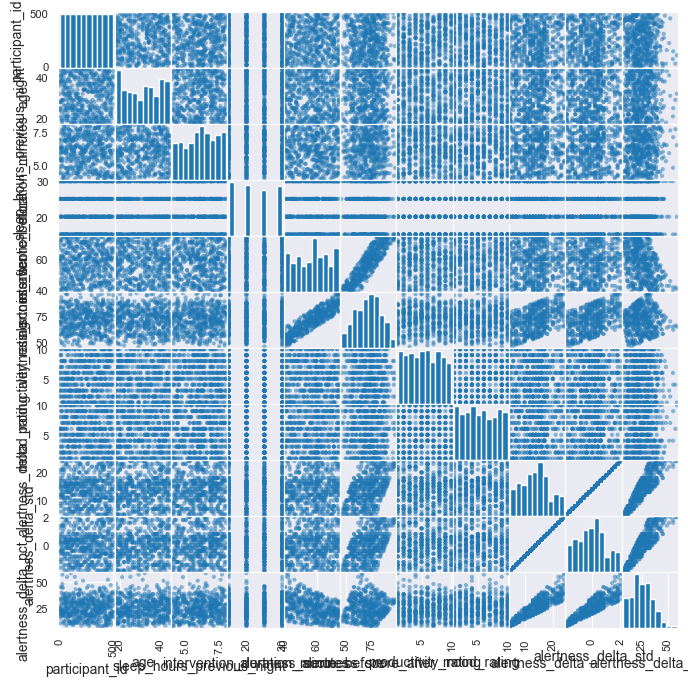

In [32]:
from pandas.plotting import scatter_matrix

num_df = df.select_dtypes(include="number")

scatter_matrix(num_df, figsize=(8,8))
plt.show()

Allertness before e after sono correlati, ed è per questo che ha senso creare una variabile, la delta allertness (v. sezione prossima).

_______________________________________________________________________

**FEATURE ENGENEERING**

Studiando a manina il dataset ho pensato di aggiungere delle colonne che possano rendere più masticabili i valori delle variabili sulla base della nostra indagine.
Nello specifico voglio aggiungere le seguenti colonne:

 1 - Alertness_delta: 

 un valore float che ci dica la differenza di alertness calcolato con la differenza fra alertness_after - alertness_before. In questo modo possiamo verificare facilmente se l'alertness è aumentata = la gente si è ripostata (se è positivo) o è diminuita = la gente non si è riposata (se è negativo)

 2 - Alertness_delta_std:

 un valore di alertness_delta standardizzato

 2 - Alertness_pct:

 un valore percentuale che ci dia un valore % quantificabile facilmente, calcolato usando il delta di alertness (punto 1) e l'alertness before (mettendo a confronto quindi quanto eri sveglio prima vs quanto è cambiato grezzo il tuo livello di alertness)

 3 - Has_side_effects

 dopo quello che ci siamo detti ieri (28/02) sulla vettorializzazione dei side effects, ho pensato che uno step intermedio utile potrebbe essere una maschera fatta male che semplicemente dica SE ci sono stati dei side effects o meno. la maschera non è una vera maschera perchè è una colonna che SI AGGIUNGE al databse, non ci si mette "sopra", ma poi la possiamo usare funzionalemnte come se fosse una maschera, ignorando (almeno a questa fase esplorativa) il problema della vettorializzazione delle variabili categoriali (che poi ho visto alice l'ha già fatta nell'altro file)

In [9]:
#Calcolo alertness_delta
df["alertness_delta"] = df["alertness_score_after"] - df["alertness_score_before"]

#Calcolo alertness_delta_std
scaler = StandardScaler()
df["alertness_delta_std"] = scaler.fit_transform(df[["alertness_delta"]])

#Calcolo alertness_delta_pct
df["alertness_delta_pct"] = df["alertness_delta"] / df["alertness_score_before"] * 100

#Creazione colonna has_side_effect
df["has_side_effect"] = df["side_effects"].astype(str).ne("None")

#chiamo le descrittive stats per le colonne appena aggiunte e vedere che suc
df[["alertness_score_before","alertness_score_after","alertness_delta","alertness_delta_std","alertness_delta_pct", "has_side_effect"]].describe()


,alertness_score_before,alertness_score_after,alertness_delta,alertness_delta_std,alertness_delta_pct
count,500.000000,500.000000,500.00000,5.000000e+02,500.000000
mean,57.380000,71.230000,13.85000,5.684342e-17,24.800598
std,9.943306,11.420067,5.04325,1.001002e+00,9.856777
min,40.000000,46.000000,5.00000,-1.756578e+00,6.756757
25%,49.000000,62.000000,10.00000,-7.641612e-01,17.443064
50%,58.000000,72.000000,14.00000,2.977251e-02,24.165740
75%,65.000000,79.250000,17.00000,6.252228e-01,31.441799
max,74.000000,97.000000,24.00000,2.014607e+00,58.536585


Metto anche qua la correlazione delle feature utilizzare, perché vogliamo usare questo dataset "aumentato"

In [10]:
le = LabelEncoder()

df_encoded = df.copy()

df_encoded["intervention_type"] = le.fit_transform(df["intervention_type"])
df_encoded = pd.get_dummies(df_encoded, columns=["occupation"])
df_encoded = pd.get_dummies(df_encoded, columns=['side_effects'])
df_corr = df_encoded.drop('participant_id', axis=1, inplace=False)
correlation = df_corr.corr()
correlation
threshold= 0.8
mask = np.abs(correlation) > threshold
mask

#questo può anche essere resa una funzione

,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,alertness_score_before,alertness_score_after,productivity_rating,mood_rating,alertness_delta,alertness_delta_std,alertness_delta_pct,has_side_effect,occupation_Freelancer,occupation_Student,occupation_Working Professional,side_effects_Anxiety,side_effects_Crash,side_effects_Grogginess,side_effects_None
age,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
sleep_hours_previous_night,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
intervention_type,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
intervention_duration_minutes,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
alertness_score_before,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
alertness_score_after,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
productivity_rating,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
mood_rating,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
alertness_delta,False,False,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False
alertness_delta_std,False,False,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False


Vedo che molte variabili create da Edo sono correlate, quindi bisogna fare una scelta (ovviamente tutti i tipi di delta sono correlati fra di loro, così come has side effect/ vs has not side effects)

OUTLIER DETECTION

In questa fase controlliamo se ci sinao outlier

In [11]:
num_cols = df.select_dtypes(include="number").columns.drop("participant_id", errors="ignore")


#Creo una funzione che calcoli in automatico interquartili e outlier per ogni colonna numerica, restituendo una maschera booleana
def iqr_outlier_mask(s: pd.Series, k: float = 1.5) -> pd.Series:
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (s < lower) | (s > upper)
#Ho fatto sta cosa per il discorso di Vandin dell'essere pythonici. Forse questo potrebbe essere messo in uno script a parte e chiamato importando lo script con tutti i metodi (ALICE PLS CHIEDI A VANDIN QUANDO VAI A LEZIONE <3)

#qui applico la mia nuova maschera a tutte le colonne numeriche e creo un DataFrame con i risultati
outlier_mask = pd.DataFrame({c: iqr_outlier_mask(df[c]) for c in num_cols})

# riepilogo: quanti outlier per colonna
outlier_summary = (
    outlier_mask.sum()
    .to_frame("n_outliers")
    .assign(pct_outliers=lambda x: (x["n_outliers"] / len(df) * 100).round(2))
    .sort_values("n_outliers", ascending=False)
)

outlier_summary

,n_outliers,pct_outliers
alertness_delta_pct,4,0.8
age,0,0.0
sleep_hours_previous_night,0,0.0
intervention_duration_minutes,0,0.0
alertness_score_before,0,0.0
alertness_score_after,0,0.0
productivity_rating,0,0.0
mood_rating,0,0.0
alertness_delta,0,0.0
alertness_delta_std,0,0.0


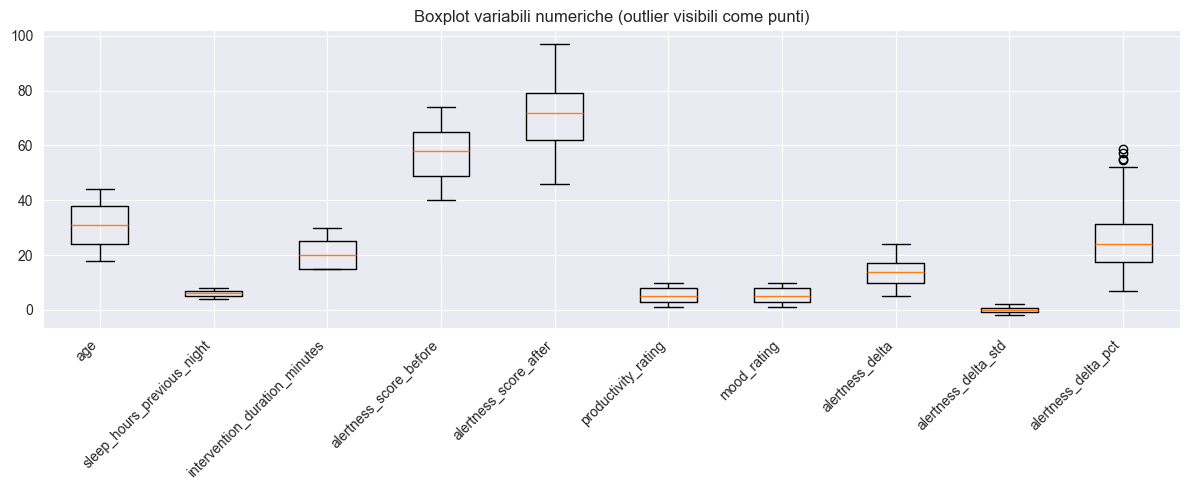

In [12]:
data = [df[c].dropna().values for c in num_cols]

plt.figure(figsize=(12, 5))
plt.boxplot(data, tick_labels=num_cols, showfliers=True)
plt.xticks(rotation=45, ha="right")
plt.title("Boxplot variabili numeriche (outlier visibili come punti)")
plt.tight_layout()
plt.show()

SUPPONENDO CHE ABBIA FATTO TUTTO BENE (che è una grossa supposizione), il nostro database **presenta solo 4 outlier** nella colonna delta% (che ho caloclato io tra l'altro). Nessun'altra colonna numerica presenta outliers, quindi penso possiamo proseguire senza dover fare nulla di particolare

_________________________________________________________________________________

ANALISI ESPLORATIVE + GRAFICHETTI

(In realtà vi chiedo scusa perchè mi rendo conto che facendo ste cose sto già inferendo tipi di analisi, ma non so come muovermi e diciamo che provo a fare cose che me sembra che abbiano senso. Se così non fosse perdonatemi e capiamo come correggere)

**PARTE 0**: La distribuzione di alcune variabili categoriali

In questa parte voglio vedere qual è la distribuzione del tipo di intervento e qual è la distruzione dei side effects, perché a pelle mi sembrano le variabili più importanti? comunque sono quelle che usiamo nelle altre fasi e se vogliamo addestrare un modello a predire i side effects o l'intervention type è una informazione utile

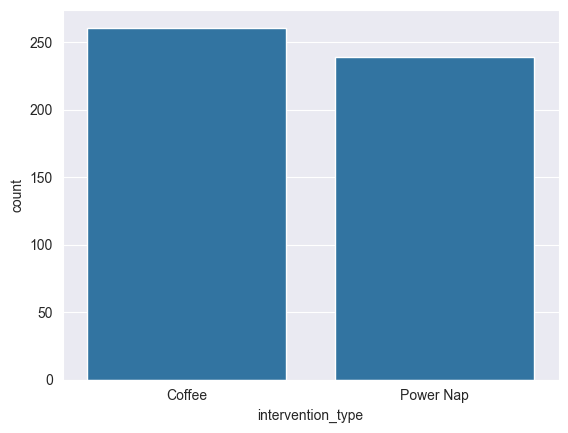

In [27]:
sns.countplot(data=df, x="intervention_type")
plt.show()

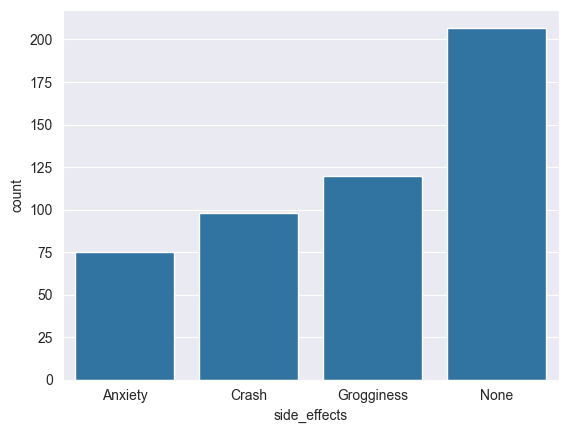

In [28]:
sns.countplot(data=df, x="side_effects")
plt.show()
plt.show()

**PARTE 1**: Intervention type x Alertness

Sto utilizzando ALERTNESS DELTA come prima variabile dipendente, usando il tipo di intervento come indipendente. 

Questo sulla base dei seguenti assunti:

 1 - che ci interessi verificare, come prima cosa quale tipo di intervento sia più "riposante"

 2 - che la nuova colonnina "alertness_delta" sia un adeguato indicatore di quanto "riposante" sia stato l'intervento

In [13]:
#descrittive per alertness_delta raggruppato per intervento
df.groupby("intervention_type")["alertness_delta"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
intervention_type,,,,,,,,
Coffee,261.0,10.93,3.86,5.0,7.0,11.0,15.0,17.0
Power Nap,239.0,17.04,4.18,10.0,14.0,17.0,21.0,24.0


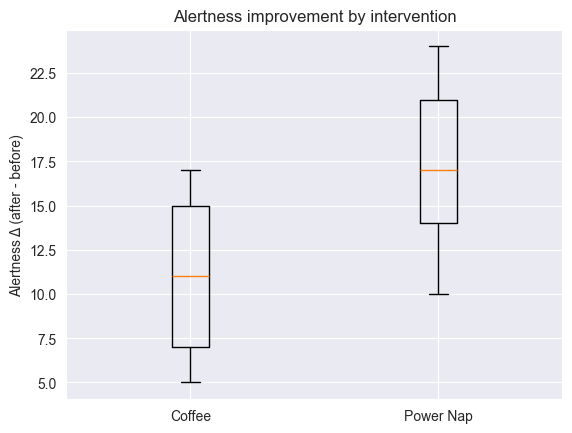

In [14]:
#Creo i miei dati d'interesse per il boxplot
data = [
    df.loc[df["intervention_type"]=="Coffee", "alertness_delta"],
    df.loc[df["intervention_type"]=="Power Nap", "alertness_delta"]
]

#Disegno il Boxplot (non ho idea di cosa sia metà di queste cose, grazie ChatGPT)
plt.boxplot(data, tick_labels=["Coffee","Power Nap"])
plt.ylabel("Alertness Δ (after - before)")
plt.title("Alertness improvement by intervention")
plt.show()

**PARTE 2**: Intervention Type x Intervention duration

Sto utilizzando Intervention duration (che ha solo 15/20/25/30) come seconda variabile dipendente, usando il tipo di intervento come indipendente. 

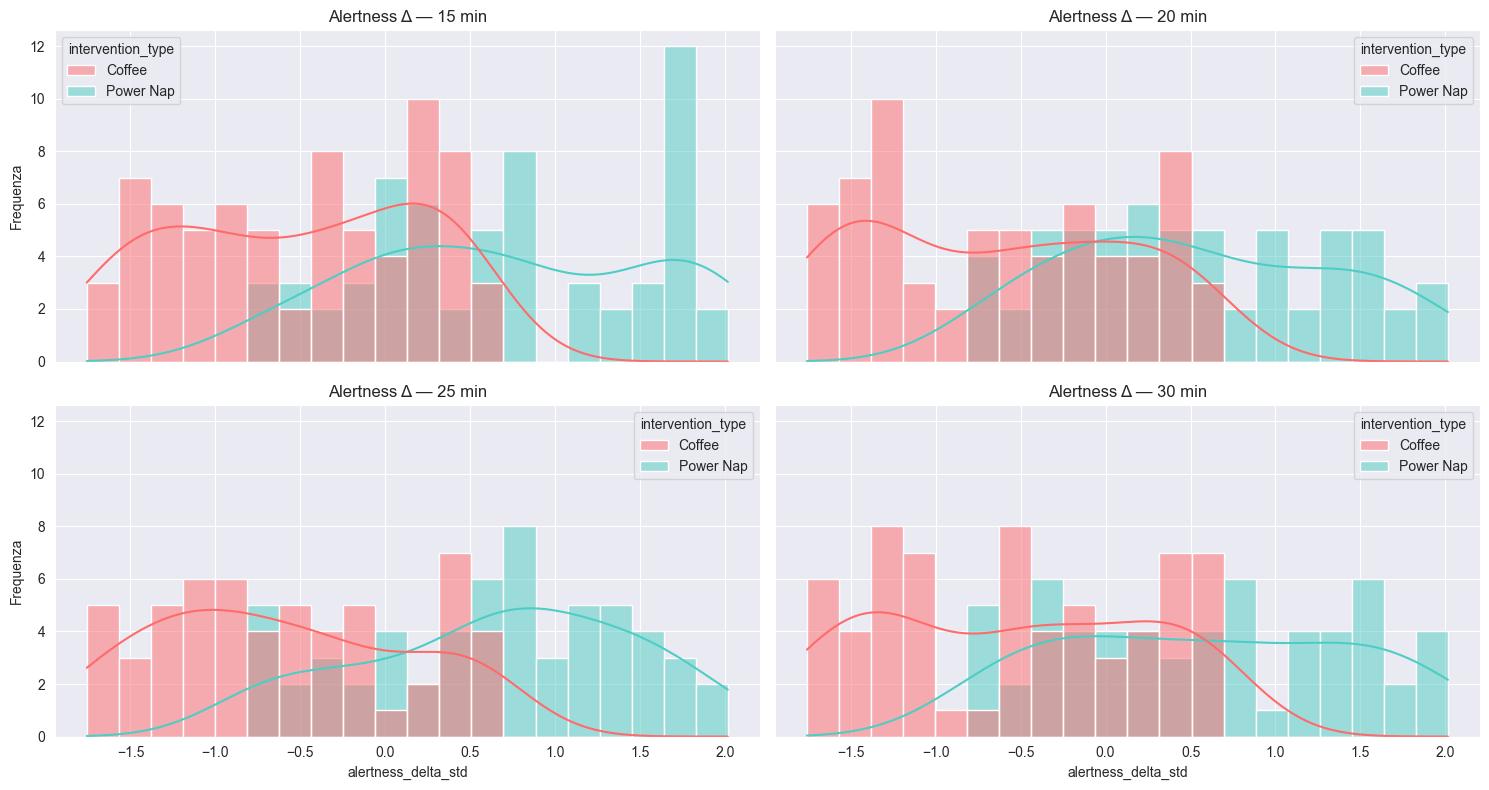

In [15]:
df_t15 = df[df["intervention_duration_minutes"] == 15]["alertness_delta_std"]
df_t20 = df[df["intervention_duration_minutes"] == 20]["alertness_delta_std"]
df_t25 = df[df["intervention_duration_minutes"] == 25]["alertness_delta_std"]
df_t30 = df[df["intervention_duration_minutes"] == 30]["alertness_delta_std"]

datasets = {
    "15 min": df_t15,
    "20 min": df_t20,
    "25 min": df_t25,
    "30 min": df_t30,
}

durations = sorted(df["intervention_duration_minutes"].unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, duration in zip(axes, durations):
    data_duration = df[df["intervention_duration_minutes"] == duration]
    
    if len(data_duration) > 0:  # Verifica che ci siano dati
        sns.histplot(
            data=data_duration,
            x="alertness_delta_std",
            hue="intervention_type",
            bins=20,
            kde=True,
            stat="count",
            ax=ax,
            palette=["#FF6B6B", "#4ECDC4"]
        )
        ax.set_title(f"Alertness Δ — {duration} min")
        ax.set_xlabel("alertness_delta_std")
        ax.set_ylabel("Frequenza")
    else:
        ax.text(0.5, 0.5, f"No data for {duration} min", ha="center", va="center")
        ax.set_title(f"Alertness Δ — {duration} min")

plt.tight_layout()
plt.show()

Osservando la distribuzione dei grafici, abbiamo scoperto che la distribuzione dell'alrtness delta, alertness_before, alertness delta % e alertness delta standardizzata non sono neanche lontanamente normali...
per questo decidiamo di studiare la mediana + fare i boxplot
 

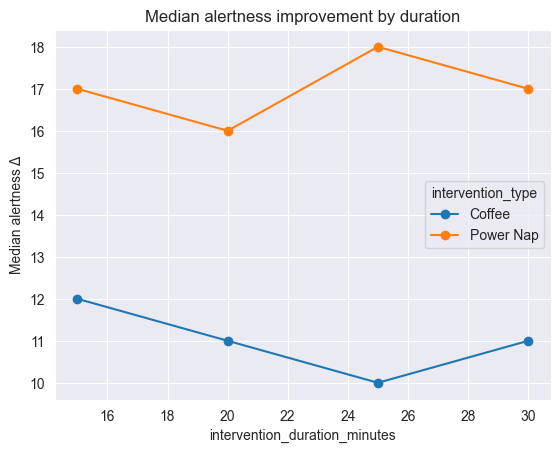

In [16]:
pivot = df.pivot_table(
    index="intervention_duration_minutes",
    columns="intervention_type",
    values="alertness_delta",
    aggfunc="median"
).sort_index()

pivot.plot(marker="o")
plt.ylabel("Median alertness Δ")
plt.title("Median alertness improvement by duration")
plt.show()

ALLORA: onesto, mi aspettavo di vedere delle interezioni fra durata di intervento e livello di alertness nel tempo, ma sto grafico m'ha spiazzato fortissimo. Cioè sembra che ci sia una CHIARISSIMA differenza nei livelli di alertness fra caffe e power nap.

[Alice: ma questo si vedeva anche dal boxplot!]

*DA DISCUTERE ASSIEME CHE VOGLIAMO FARE CON QUESTI DATI*

Alice: Intanto io faccio i boxplot per delta allertness e intervention duration, dato che funzionano meglio per le distribuzioni non normali. Prima faccio solo l'allertness improvement vs duration time, e si vede che il delta non cambia. Questo conferma l'importanza di studiare l'intersezione fra metodo vs duration

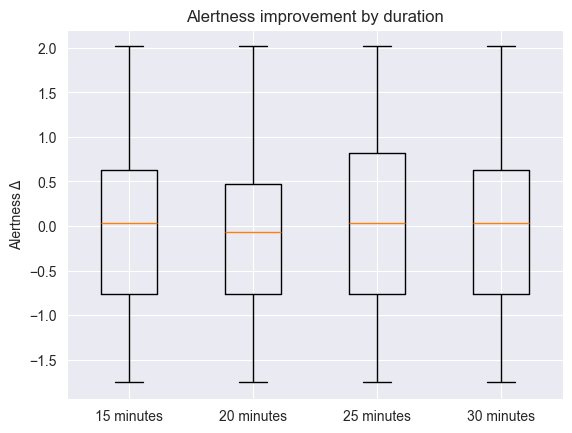

In [17]:
durations = [15, 20, 25, 30]
df_duration = [df[(df["intervention_duration_minutes"]==d)]["alertness_delta_std"]
    for d in durations]

#Disegno il Boxplot (non ho idea di cosa sia metà di queste cose, grazie ChatGPT)
plt.boxplot(df_duration, tick_labels=["15 minutes","20 minutes", "25 minutes", "30 minutes"])
plt.ylabel("Alertness Δ")
plt.title("Alertness improvement by duration")
plt.show()

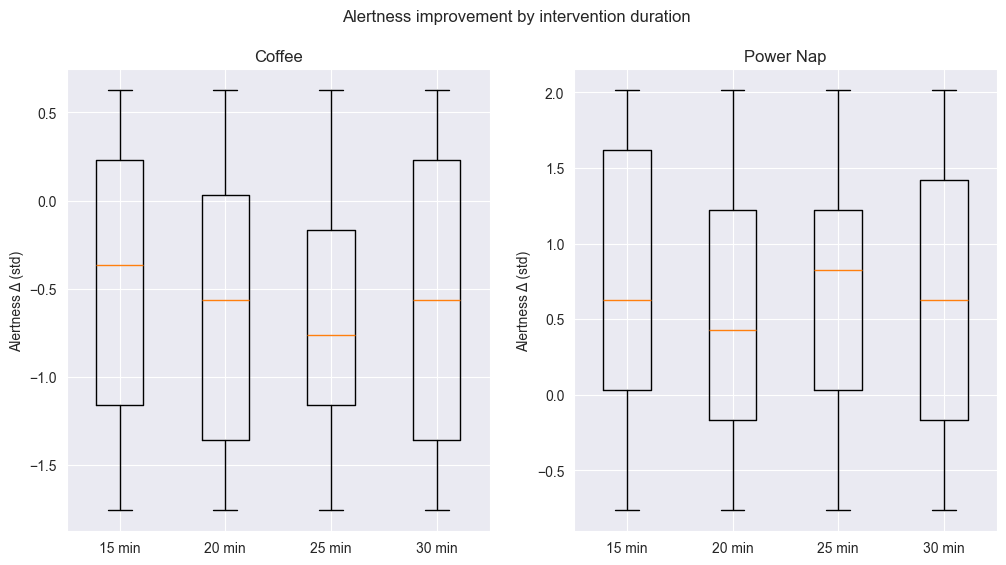

In [18]:
import matplotlib.pyplot as plt

durations = [15, 20, 25, 30]

# Coffee
coffee_data = [
    df[(df["intervention_type"]=="Coffee") & (df["intervention_duration_minutes"]==d)]["alertness_delta_std"]
    for d in durations
]

# Power Nap
nap_data = [
    df[(df["intervention_type"]=="Power Nap") & (df["intervention_duration_minutes"]==d)]["alertness_delta_std"]
    for d in durations
]

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Boxplot Coffee
axes[0].boxplot(coffee_data, tick_labels=[f"{d} min" for d in durations])
axes[0].set_title("Coffee")
axes[0].set_ylabel("Alertness Δ (std)")

# Boxplot Power Nap
axes[1].boxplot(nap_data, tick_labels=[f"{d} min" for d in durations])
axes[1].set_title("Power Nap")
axes[1].set_ylabel("Alertness Δ (std)")

plt.suptitle("Alertness improvement by intervention duration")
plt.show()

Alice: comunque si vede che questo dataset non è di italiani, chi cazzo si beve un caffè in mezz'ora? Comunque possiamo concludere che, considerando la mediana, i power nap di 25 minuti sono più efficaci. Comunque ha senso standardizzare il delta? Io non ne sono così sicura, quindi provo a rifarlo con la versione non standardizzata

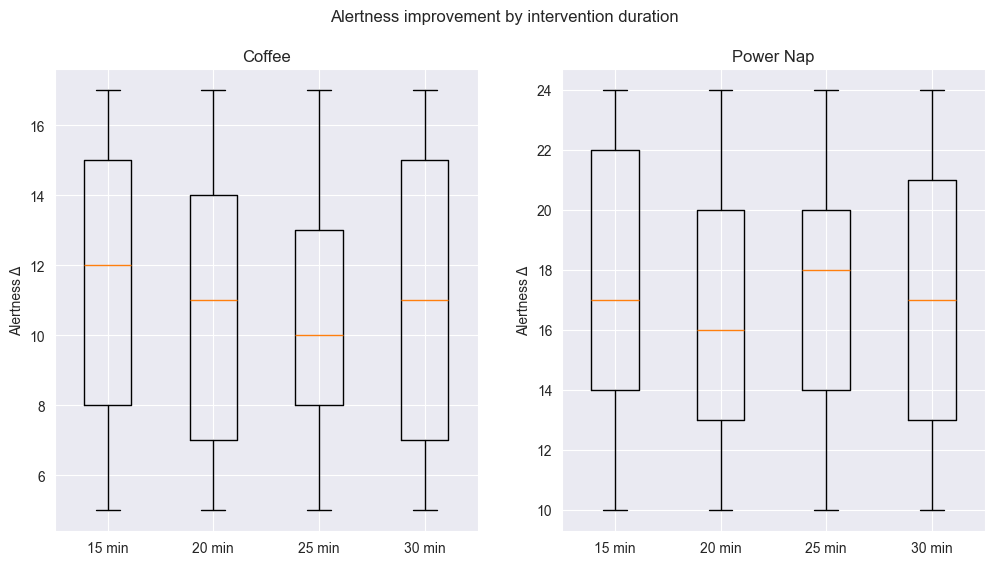

In [19]:
import matplotlib.pyplot as plt

durations = [15, 20, 25, 30]

# Coffee
coffee_data = [
    df[(df["intervention_type"]=="Coffee") & (df["intervention_duration_minutes"]==d)]["alertness_delta"]
    for d in durations
]

# Power Nap
nap_data = [
    df[(df["intervention_type"]=="Power Nap") & (df["intervention_duration_minutes"]==d)]["alertness_delta"]
    for d in durations
]

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Boxplot Coffee
axes[0].boxplot(coffee_data, tick_labels=[f"{d} min" for d in durations])
axes[0].set_title("Coffee")
axes[0].set_ylabel("Alertness Δ")

# Boxplot Power Nap
axes[1].boxplot(nap_data, tick_labels=[f"{d} min" for d in durations])
axes[1].set_title("Power Nap")
axes[1].set_ylabel("Alertness Δ")

plt.suptitle("Alertness improvement by intervention duration")
plt.show()

Ok, non cambia niente, ma va comunque motivata la standardizzazione (Edo fallo te ciauxxx)
Comunque, in conclusione, non cè una forte correlazione fra allertness delta e durata dell'intervento: questo di vede sia distinguendo il tipo di intervento, che non facendolo.

**PARTE 3**: Intervention Type X has side effects

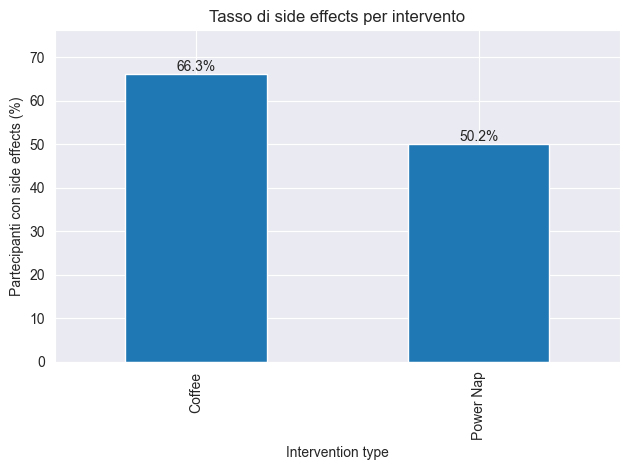

In [20]:
rate = df.groupby("intervention_type")["has_side_effect"].mean().sort_values(ascending=False)
rate


#come sempre, tutta la parte dei grafici l'ha fatta GPT, no idea di cosa significhi
ax = (rate * 100).plot(kind="bar")  # percentuale
plt.ylabel("Partecipanti con side effects (%)")
plt.xlabel("Intervention type")
plt.title("Tasso di side effects per intervento")
plt.ylim(0, max((rate*100).max() * 1.15, 5))  # un po' di spazio sopra

# Etichette sopra le barre
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

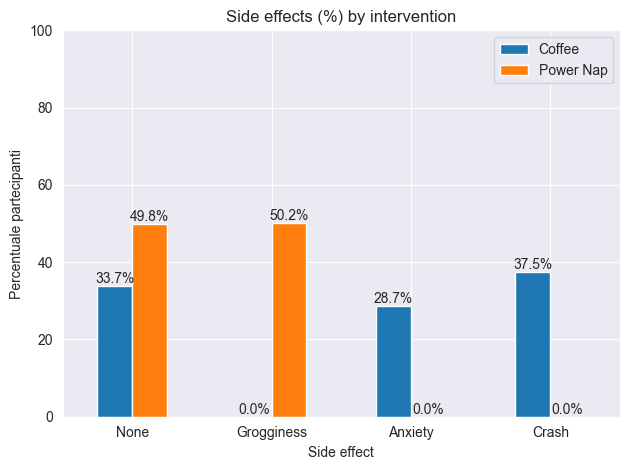

In [24]:
import matplotlib.pyplot as plt

side_effects = ["None", "Grogginess", "Anxiety", "Crash"]

# percentuali per Coffee
coffee_pct = (
    df[df["intervention_type"] == "Coffee"]["side_effects"]
    .value_counts(normalize=True)
    .reindex(side_effects, fill_value=0)
)

# percentuali per Power Nap
nap_pct = (
    df[df["intervention_type"] == "Power Nap"]["side_effects"]
    .value_counts(normalize=True)
    .reindex(side_effects, fill_value=0)
)

# dataframe unico
plot_df = (
    (100 *
     pd.DataFrame({
        "Coffee": coffee_pct,
        "Power Nap": nap_pct
     }))
)

ax = plot_df.plot(kind="bar")

plt.title("Side effects (%) by intervention")
plt.xlabel("Side effect")
plt.ylabel("Percentuale partecipanti")
plt.ylim(0, 100)
plt.xticks(rotation=0)

# etichette percentuali
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1f}%",
                (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

Vediamo quindi che i power nap danno meno side effects rispetto al caffè, e che i tipi di sintomi sono dipendono dal tipo di intervento